<a href="https://colab.research.google.com/github/Arnaldo-Algave/challenge_Alura_store/blob/main/AluraStoreBrasil.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Importação dos dados



In [1]:
import pandas as pd
import matplotlib.pyplot as plt

url = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science/refs/heads/main/base-de-dados-challenge-1/loja_1.csv"
url2 = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science/refs/heads/main/base-de-dados-challenge-1/loja_2.csv"
url3 = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science/refs/heads/main/base-de-dados-challenge-1/loja_3.csv"
url4 = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science/refs/heads/main/base-de-dados-challenge-1/loja_4.csv"

loja = pd.read_csv(url)
loja2 = pd.read_csv(url2)
loja3 = pd.read_csv(url3)
loja4 = pd.read_csv(url4)

loja.head()

,Produto,Categoria do Produto,Preço,Frete,Data da Compra,Vendedor,Local da compra,Avaliação da compra,Tipo de pagamento,Quantidade de parcelas,lat,lon
0,Assistente virtual,eletronicos,219.08,9.249790,16/01/2021,Pedro Gomes,SP,4,cartao_credito,8,-22.19,-48.79
1,Mesa de jantar,moveis,256.35,11.234305,18/05/2022,Beatriz Moraes,RJ,1,cartao_credito,4,-22.25,-42.66
2,Jogo de tabuleiro,brinquedos,279.51,21.262681,15/03/2021,João Souza,DF,1,cartao_credito,1,-15.83,-47.86
3,Micro-ondas,eletrodomesticos,1009.99,54.667344,03/05/2022,João Souza,RS,4,boleto,1,-30.17,-53.50
4,Cadeira de escritório,moveis,446.99,26.964689,07/11/2020,Larissa Alves,MG,5,boleto,1,-18.10,-44.38


#1. Análise do faturamento



In [2]:
faturamento_total_loja1 = loja['Preço'].sum()
print(f"Faturamento total da loja 1: R$ {faturamento_total_loja1:.2f}")


Faturamento total da loja 1: R$ 1534509.12


In [3]:
faturamento_total_loja2 = loja2['Preço'].sum()
print(f"Faturamento total da loja 2: R$ {faturamento_total_loja2:.2f}")

Faturamento total da loja 2: R$ 1488459.06


In [4]:
faturamento_total_loja3 = loja3['Preço'].sum()
print(f"Faturamento total da loja 3: R$ {faturamento_total_loja3:.2f}")

Faturamento total da loja 3: R$ 1464025.03


In [5]:
faturamento_total_loja4 = loja4['Preço'].sum()
print(f"Faturamento total da loja 4: R$ {faturamento_total_loja4:.2f}")

Faturamento total da loja 4: R$ 1384497.58


In [6]:
faturamento_de_todas_as_lojas = pd.concat([loja, loja2, loja3, loja4], ignore_index=True)
faturamento_total_de_todas_as_lojas = faturamento_de_todas_as_lojas['Preço'].sum()
faturamento_total_de_todas_as_lojas

np.float64(5871490.790000001)

# 2. Vendas por Categoria

In [7]:
loja[' Loja '] = 'Loja 1'
loja2[' Loja '] = 'Loja 2'
loja3[' Loja '] = 'Loja 3'
loja4[' Loja '] = 'Loja 4'

lojas_unificadas = pd.concat([loja, loja2, loja3, loja4], ignore_index=True)

# 3. Média de Avaliação das Lojas


In [8]:
avaliacao_media_por_loja = lojas_unificadas.groupby(' Loja ')['Avaliação da compra'].mean().reset_index()

avaliacao_media_por_loja.rename(columns={'Avaliação da compra': 'Média de Avaliação'}, inplace=True)

print("Média das avaliações dos Cliente por loja:\n")
display(avaliacao_media_por_loja.sort_values(by='Média de Avaliação', ascending=False))

Média das avaliações dos Cliente por loja:



,Loja,Média de Avaliação
2,Loja 3,4.048326
1,Loja 2,4.037304
3,Loja 4,3.995759
0,Loja 1,3.976685


# 4. Produtos Mais e Menos Vendidos

In [9]:
vendas_por_produto = lojas_unificadas.groupby([' Loja ', 'Produto']).size().reset_index(name='Quantidade Vendida')

mais_menos_vendidos = []

for loja_nome in lojas_unificadas[' Loja '].unique():
    dados_loja = vendas_por_produto[vendas_por_produto[' Loja '] == loja_nome]

    mais_vendido = dados_loja.loc[dados_loja['Quantidade Vendida'].idxmax()]

    menos_vendido = dados_loja.loc[dados_loja['Quantidade Vendida'].idxmin()]

    mais_menos_vendidos.append({
        ' Loja ': loja_nome,
        'Produto Mais Vendido': mais_vendido['Produto'],
        'Quantidade Mais Vendida': mais_vendido['Quantidade Vendida'],
        'Produto Menos Vendido': menos_vendido['Produto'],
        'Quantidade Menos Vendida': menos_vendido['Quantidade Vendida']
    })

resumo_vendas = pd.DataFrame(mais_menos_vendidos)

print("Produtos mais e menos vendidos por loja:\n")
display(resumo_vendas.sort_values(by='Quantidade Mais Vendida', ascending=False))


Produtos mais e menos vendidos por loja:



,Loja,Produto Mais Vendido,Quantidade Mais Vendida,Produto Menos Vendido,Quantidade Menos Vendida
1,Loja 2,Iniciando em programação,65,Jogo de tabuleiro,32
3,Loja 4,Cama box,62,Guitarra,33
0,Loja 1,Guarda roupas,60,Celular ABXY,33
2,Loja 3,Kit banquetas,57,Blocos de montar,35


# 5. Frete Médio por Loja

In [10]:
lojas_unificadas.columns = lojas_unificadas.columns.str.strip()

frete_medio_por_loja = lojas_unificadas.groupby('Loja')['Frete'].mean().reset_index()

frete_medio_por_loja.rename(columns={'Frete': 'Custo Médio de Frete'}, inplace=True)

print("Custo médio de frete por loja:\n")
display(frete_medio_por_loja.sort_values(by='Custo Médio de Frete', ascending=False))

Custo médio de frete por loja:



,Loja,Custo Médio de Frete
0,Loja 1,34.691805
1,Loja 2,33.621941
2,Loja 3,33.074464
3,Loja 4,31.278997


In [11]:
print(lojas_unificadas.columns)


Index(['Produto', 'Categoria do Produto', 'Preço', 'Frete', 'Data da Compra',
       'Vendedor', 'Local da compra', 'Avaliação da compra',
       'Tipo de pagamento', 'Quantidade de parcelas', 'lat', 'lon', 'Loja'],
      dtype='object')


In [12]:
lojas_unificadas.columns.duplicated()


array([False, False, False, False, False, False, False, False, False,
       False, False, False, False])

In [13]:
lojas_unificadas = lojas_unificadas.loc[:, ~lojas_unificadas.columns.duplicated()]


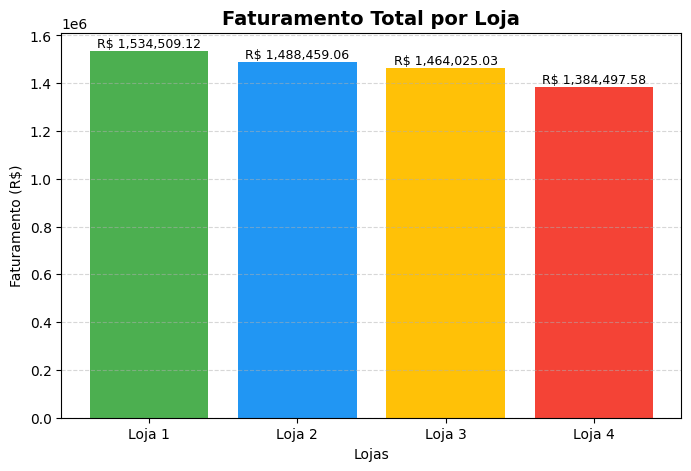

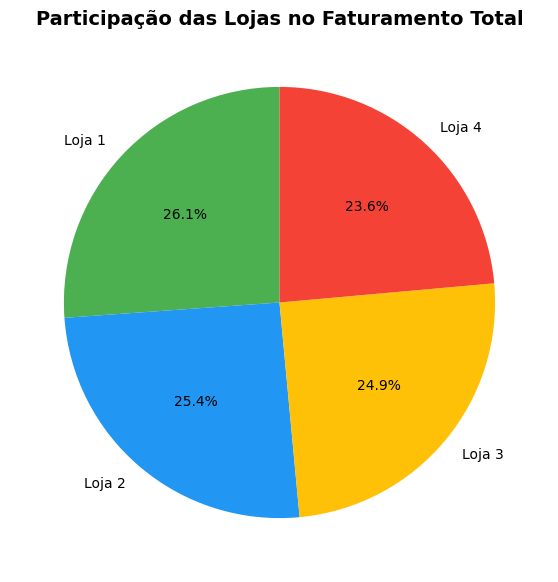

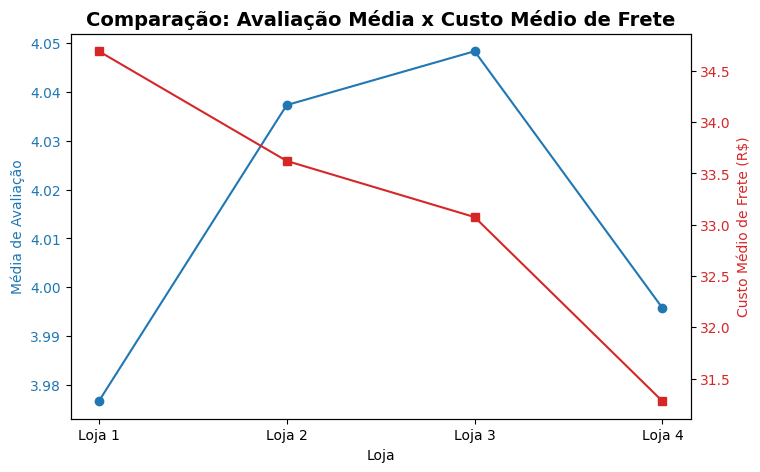

In [14]:

# GRÁFICO DE BARRAS – FATURAMENTO TOTAL POR LOJA

faturamento = {
    'Loja 1': faturamento_total_loja1,
    'Loja 2': faturamento_total_loja2,
    'Loja 3': faturamento_total_loja3,
    'Loja 4': faturamento_total_loja4
}

plt.figure(figsize=(8,5))
plt.bar(faturamento.keys(), faturamento.values(), color=['#4CAF50','#2196F3','#FFC107','#F44336'])
plt.title('Faturamento Total por Loja', fontsize=14, fontweight='bold')
plt.xlabel('Lojas')
plt.ylabel('Faturamento (R$)')
plt.grid(axis='y', linestyle='--', alpha=0.5)

for i, valor in enumerate(faturamento.values()):
    plt.text(i, valor + (valor * 0.01), f"R$ {valor:,.2f}", ha='center', fontsize=9)

plt.show()

### GRÁFICO DE PIZZA – PARTICIPAÇÃO DE CADA LOJA NO FATURAMENTO TOTAL
plt.figure(figsize=(7,7))
plt.pie(faturamento.values(),
        labels=faturamento.keys(),
        autopct='%1.1f%%',
        startangle=90,
        colors=['#4CAF50','#2196F3','#FFC107','#F44336'])
plt.title('Participação das Lojas no Faturamento Total', fontsize=14, fontweight='bold')
plt.show()

### GRÁFICO DE LINHAS – AVALIAÇÃO MÉDIA X CUSTO MÉDIO DE FRETE

avaliacao_media_por_loja.columns = avaliacao_media_por_loja.columns.str.strip()
frete_medio_por_loja.columns = frete_medio_por_loja.columns.str.strip()

fig, ax1 = plt.subplots(figsize=(8,5))

ax1.plot(avaliacao_media_por_loja['Loja'], avaliacao_media_por_loja['Média de Avaliação'],
         color='tab:blue', marker='o', label='Média de Avaliação')
ax1.set_xlabel('Loja')
ax1.set_ylabel('Média de Avaliação', color='tab:blue')
ax1.tick_params(axis='y', labelcolor='tab:blue')

ax2 = ax1.twinx()
ax2.plot(frete_medio_por_loja['Loja'], frete_medio_por_loja['Custo Médio de Frete'],
         color='tab:red', marker='s', label='Custo Médio de Frete')
ax2.set_ylabel('Custo Médio de Frete (R$)', color='tab:red')
ax2.tick_params(axis='y', labelcolor='tab:red')

plt.title('Comparação: Avaliação Média x Custo Médio de Frete', fontsize=14, fontweight='bold')
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.show()



                Relatório Final

# **Introdução**

O presente relatório foi feito para analisar o desempenho das lojas administradas pelo Senhor João, a fim de identificar qual delas apresenta os piores resultados e, portanto, deve ser vendida, para que o mesmo faça investimento em um novo negócio. Realizei a avaliação de diversos indicadores de desempenho que são:

- Faturamento total por loja

- Categorias de produtos mais e menos vendidas

- Média das avaliações dos clientes

- Produtos mais e menos vendidos

- Frete médio por loja

# **Desenvolvimento da Análise**
### 1. Faturamento Total das Lojas.

Analisando o gráfico de faturamento total, é possível verificar o desempenho financeiro de cada loja, a loja com menor faturamento já demonstra fragilidade competitiva e menor capacidade de geração de caixa, e nesse caso a Loja 04 é a que aparece com o menor faturamento como mostra o gráfico a baixo.

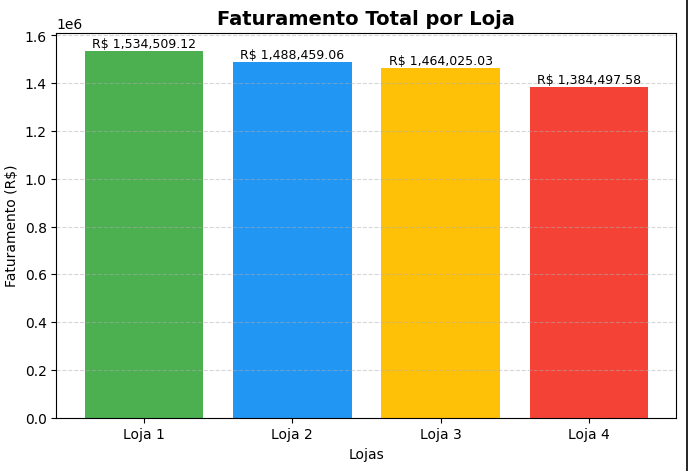

In [33]:
from IPython.display import Image
Image('/content/sample_data/tabela_faturamento.png')

### 2. Categorias mais e menos vendidas
Realizar a análise das categorias me permitiu entender quais categorias de produtos de cada loja tem menos saída e por serem poucos vendidas tendem a ser menos lucrativa. Importante pontuar que dentre as categorias menos vendidas, **utilidades domesticas** é a categoria que se destaca negativamente.



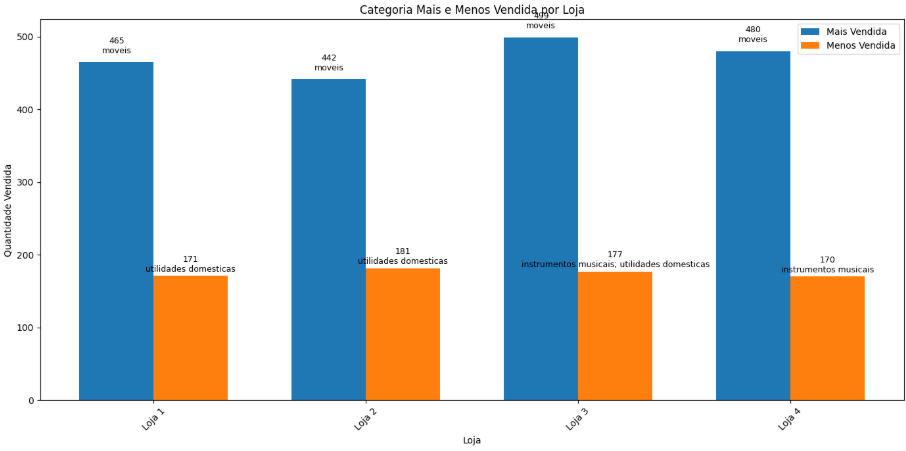

In [32]:
from IPython.display import Image
Image('/content/sample_data/categoria_mais_e_menos_vendidos.png')

### 3. Avaliação Média dos Clientes
A avaliação média dos clientes é um indicador essencial para medir a qualidade da experiência oferecida pela loja. Ela reflete diretamente a percepção do consumidor sobre diversos aspectos, como qualidade dos produtos, tempo de entrega, atendimento e confiança na marca.

Uma avaliação baixa pode sinalizar problemas recorrentes em algum desses pontos, impactando negativamente a reputação da loja e, consequentemente, suas vendas. Por outro lado, boas avaliações reforçam a satisfação do cliente e aumentam as chances de recompra e fidelização. No cenário que nos foi apresentado, a Loja 01 é a que apresenta a pior avaliação entre as 4 lojas do senhor João.

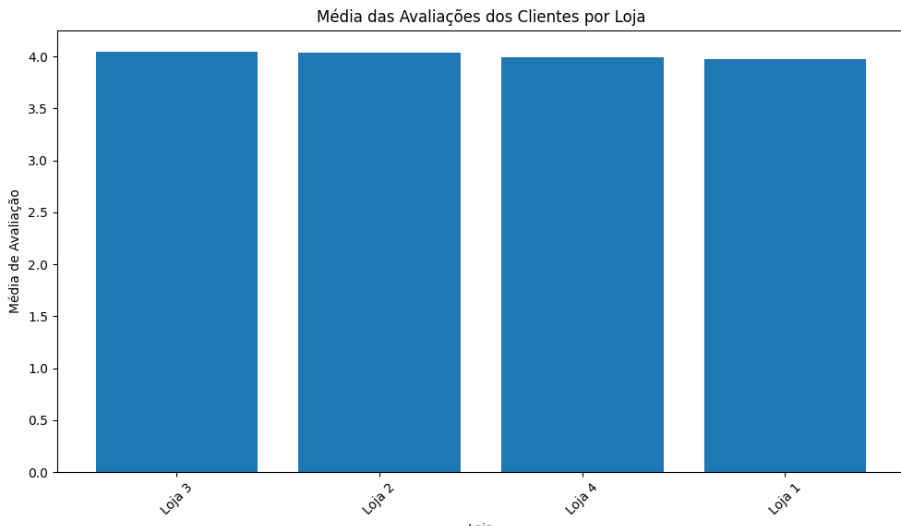

In [31]:
from IPython.display import Image
Image('/content/sample_data/avaliação_cliente_por_loja.png')

### 4. Produtos mais e menos vendidos

 A análise dos produtos mais e menos vendidos possibilita identificar o desempenho do portfólio de cada loja. Esse exame evidencia não apenas os itens de maior aceitação pelos consumidores, mas também permite reconhecer possíveis gargalos relacionados à gestão de estoque. Lojas que apresentam um volume elevado de produtos com baixa rotatividade, comumente denominados “produtos encalhados”, tendem a demonstrar menor eficiência operacional e redução em sua competitividade no mercado.

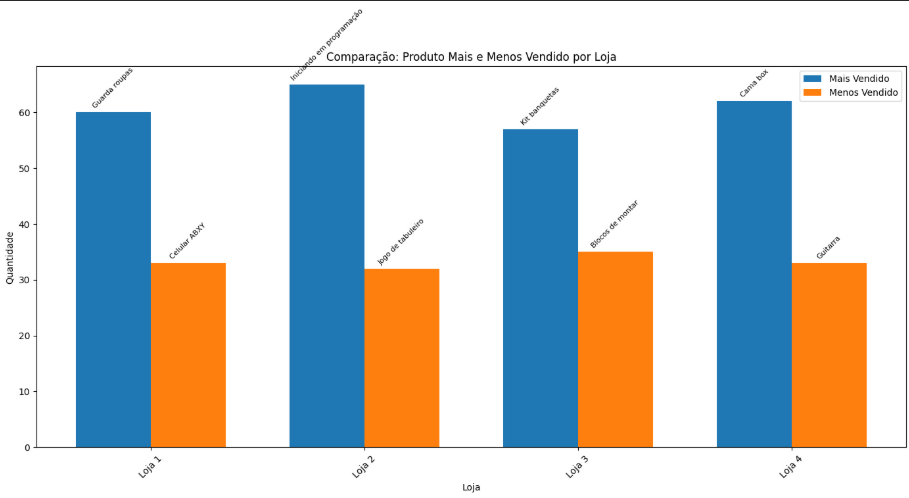

In [30]:
from IPython.display import Image
Image('/content/sample_data/mais_e_menos_vendidos.png')

### 5. Custo Médio de Frete por Loja

 Como o valor do frete influencia diretamente a decisão de compra dos clientes, lojas com custos mais elevados tendem a registrar menor taxa de conversão e maior desistência no checkout. Dessa forma, observa-se que a Loja 1, por possuir o frete mais alto, pode enfrentar maior dificuldade para atrair compradores, enquanto a Loja 4 tem vantagem estratégica ao oferecer o menor custo médio entre as unidades analisadas.

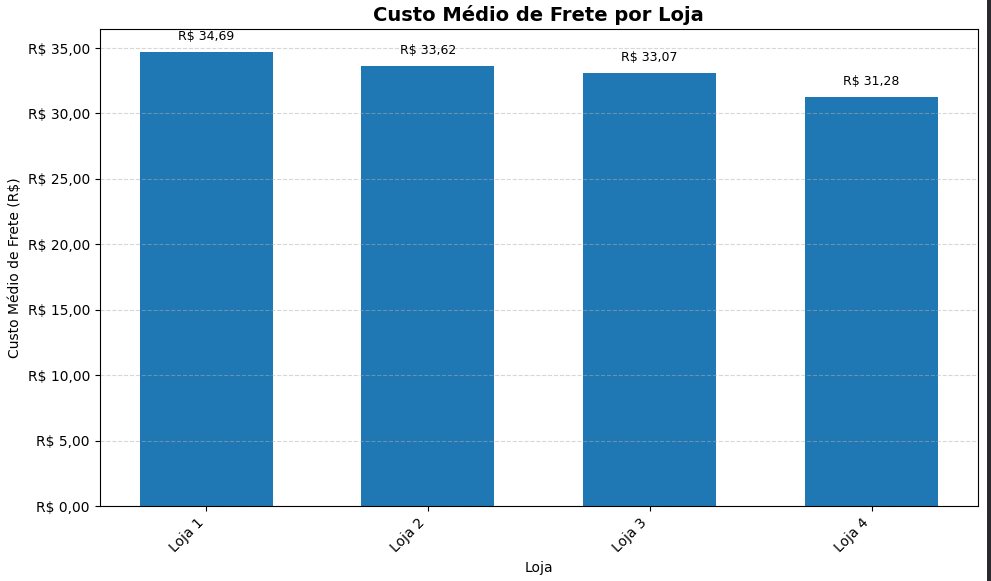

In [29]:
from IPython.display import Image
Image('/content/sample_data/custo_medio_frete.png')


#**Conclusão**

Após a análise completa dos indicadores de desempenho das quatro lojas do Senhor João, dos indicadores que são: faturamento total por loja, categorias de produtos mais e menos vendidos por loja, avaliação média dos clientes por loja, produto mais e menos vendido e custo médio de frete; foi possível identificar de forma objetiva qual unidade apresenta os resultados mais desfavoráveis.

Os dados mostram que a Loja 04 é a que possui o menor faturamento total entre todas, o que evidencia menor competitividade e reduzida capacidade de geração de caixa. Além disso, o desempenho nas categorias e nos produtos vendidos demonstra menor força comercial em comparação às demais lojas. Apesar de apresentar o menor custo médio de frete, essa vantagem operacional não é suficiente para compensar os resultados negativos em outros indicadores mais relevantes.

Diante disso, conclui-se que a **Loja 04** é a unidade que apresenta o pior desempenho geral e, portanto, é a mais indicada para ser vendida. Essa decisão permitirá ao Senhor João reduzir custos, otimizar recursos e direcionar investimentos para negócios ou lojas com maior potencial de retorno.

In [20]:
lojas_unificadas['lat'] = lojas_unificadas['lat'].astype(float)
lojas_unificadas['lon'] = lojas_unificadas['lon'].astype(float)

lojas_unificadas[['lat', 'lon']].isna().sum()


,0
lat,0
lon,0


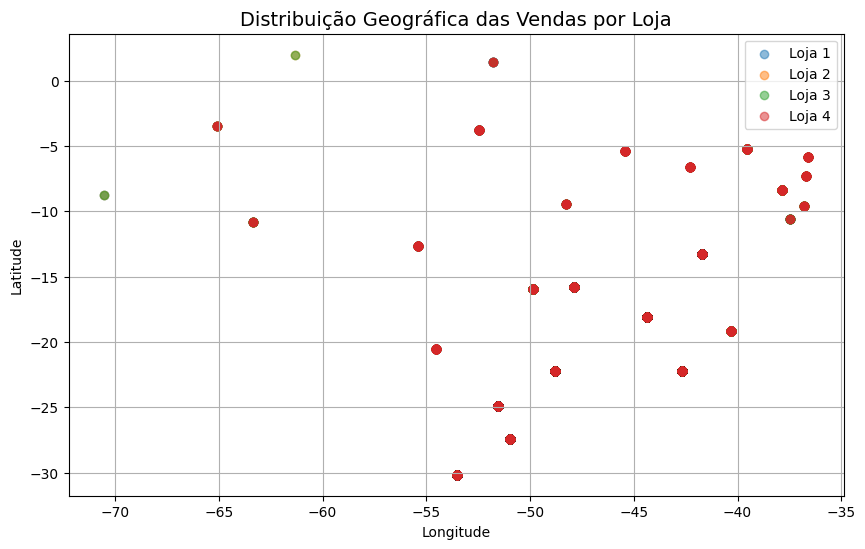

In [21]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

for loja_nome, dados in lojas_unificadas.groupby('Loja'):
    plt.scatter(
        dados['lon'], dados['lat'],
        label=loja_nome,
        alpha=0.5
    )

plt.title("Distribuição Geográfica das Vendas por Loja", fontsize=14)
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.legend()
plt.grid(True)
plt.show()


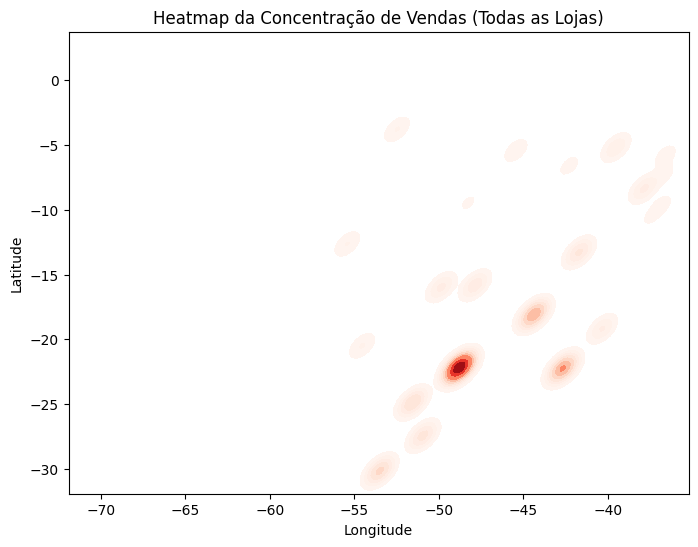

In [22]:
import seaborn as sns

plt.figure(figsize=(8,6))
sns.kdeplot(
    x=lojas_unificadas['lon'],
    y=lojas_unificadas['lat'],
    cmap="Reds",
    fill=True,
    bw_adjust=0.5
)
plt.title("Heatmap da Concentração de Vendas (Todas as Lojas)")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.show()


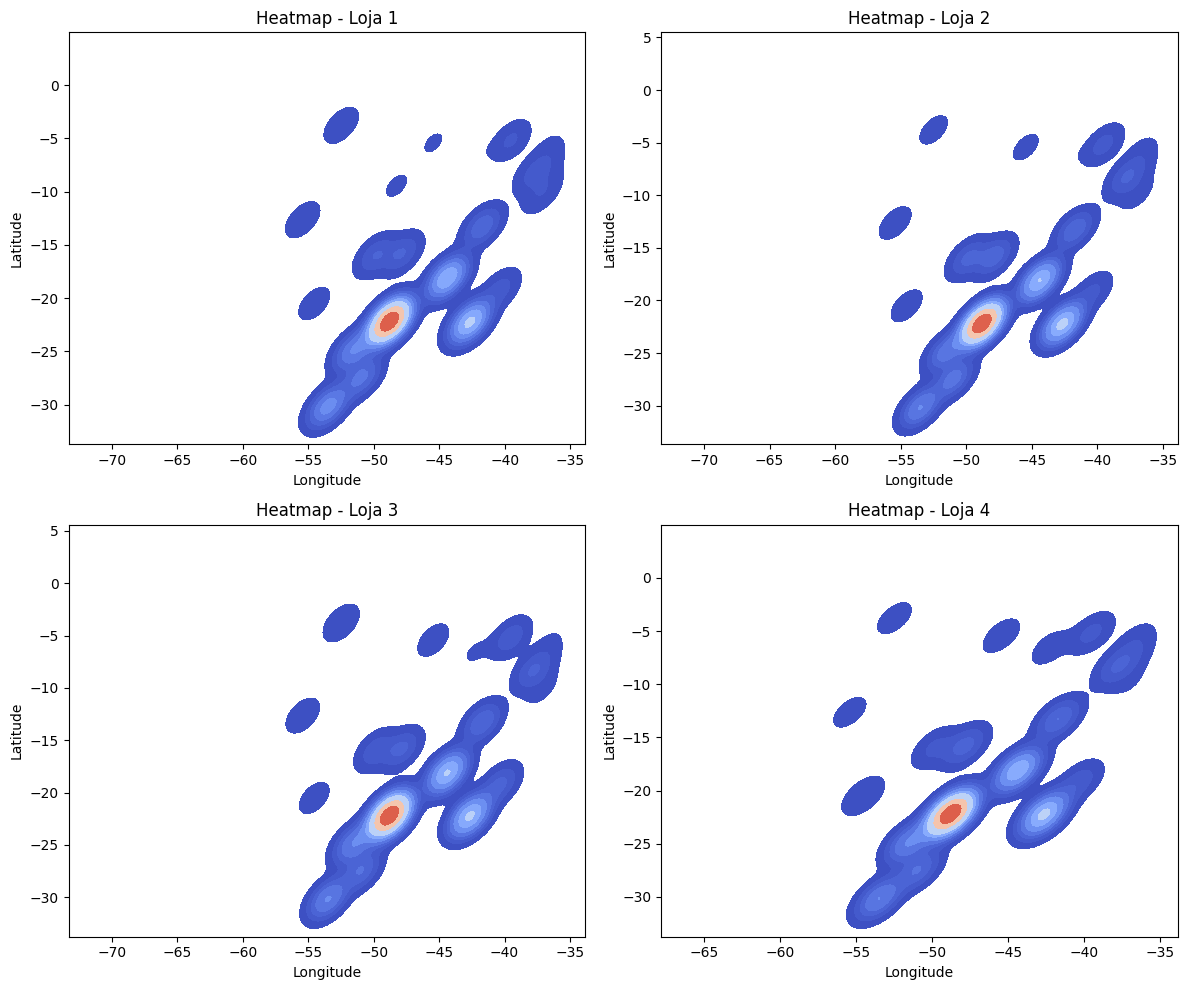

In [23]:
plt.figure(figsize=(12,10))

for idx, (loja_nome, dados) in enumerate(lojas_unificadas.groupby('Loja'), 1):
    plt.subplot(2,2,idx)
    sns.kdeplot(
        x=dados['lon'],
        y=dados['lat'],
        cmap="coolwarm",
        fill=True,
        bw_adjust=0.8
    )
    plt.title(f"Heatmap - {loja_nome}")
    plt.xlabel("Longitude")
    plt.ylabel("Latitude")

plt.tight_layout()
plt.show()



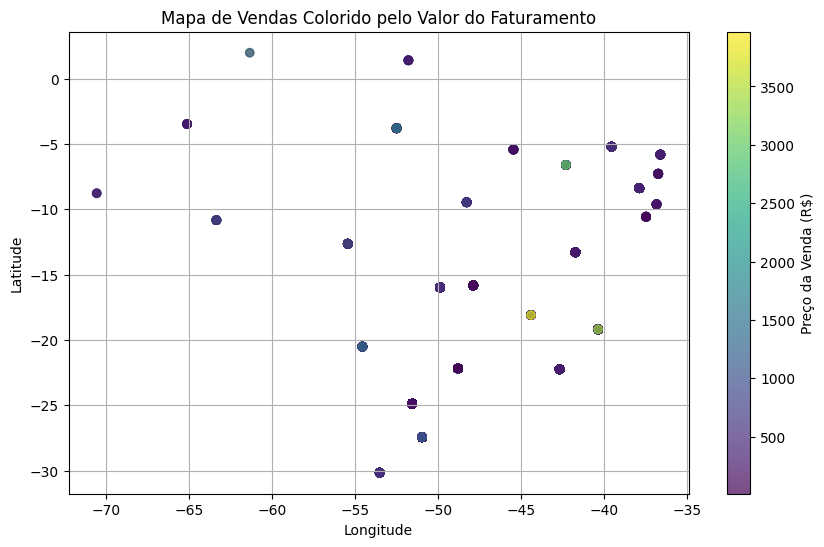

In [24]:
plt.figure(figsize=(10,6))
plt.scatter(
    lojas_unificadas['lon'],
    lojas_unificadas['lat'],
    c=lojas_unificadas['Preço'],
    cmap='viridis',
    alpha=0.7
)
plt.colorbar(label='Preço da Venda (R$)')
plt.title("Mapa de Vendas Colorido pelo Valor do Faturamento")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.grid()
plt.show()


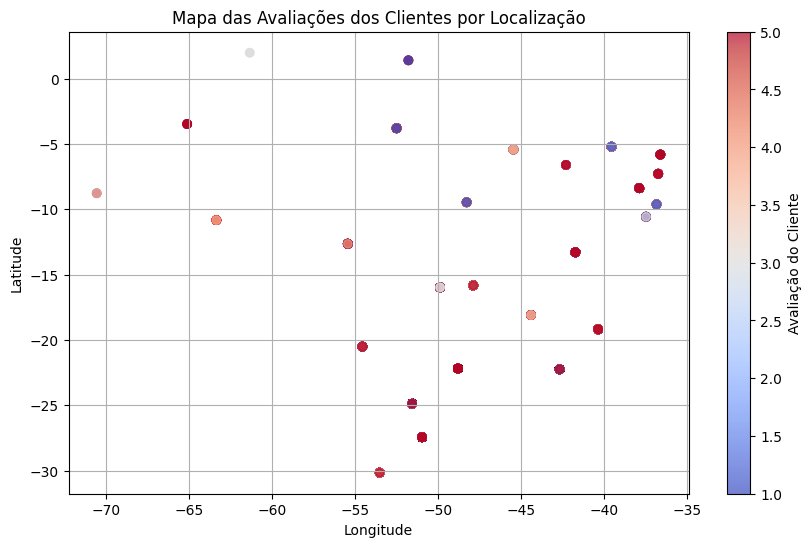

In [25]:
plt.figure(figsize=(10,6))
plt.scatter(
    lojas_unificadas['lon'],
    lojas_unificadas['lat'],
    c=lojas_unificadas['Avaliação da compra'],
    cmap='coolwarm',
    alpha=0.7
)
plt.colorbar(label='Avaliação do Cliente')
plt.title("Mapa das Avaliações dos Clientes por Localização")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.grid()
plt.show()
